# Importing Packages & Datasets to Dataframes

In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

import seaborn as sns                       
import matplotlib.pyplot as plt             
%matplotlib inline     
sns.set(color_codes=True)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

/kaggle/input/datasets/haleyblairmsds/all-data-provided/data_source_final.xlsx


In [2]:
asset_oec=pd.read_excel("/kaggle/input/datasets/haleyblairmsds/all-data-provided/data_source_final.xlsx", sheet_name='asset_oec', parse_dates=True)
market_map = pd.read_excel("/kaggle/input/datasets/haleyblairmsds/all-data-provided/data_source_final.xlsx", sheet_name='market_mapping', parse_dates=True)
rentals = pd.read_excel("/kaggle/input/datasets/haleyblairmsds/all-data-provided/data_source_final.xlsx", sheet_name='rentals', parse_dates=True)

# Exploratory Data Analysis

## Asset Data

In [3]:
asset_oec.head()

,asset_id,market_id,acquisition_date,equipment_class,oec
0,17891.0,9.0,2017-11-01,Dirt,185400.00
1,17751.0,2.0,2017-11-01,Aerial,151261.20
2,6654.0,9.0,2017-01-01,Aerial,149028.84
3,4058.0,1.0,2016-01-01,Aerial,147600.00
4,5469.0,6877.0,2016-01-01,Dirt,144720.00


In [4]:
asset_oec.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4927 entries, 0 to 4926
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   asset_id          3903 non-null   float64       
 1   market_id         3903 non-null   float64       
 2   acquisition_date  3903 non-null   datetime64[ns]
 3   equipment_class   4906 non-null   object        
 4   oec               3903 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 192.6+ KB


More equipment_class values than any other column 

In [5]:
asset_oec.isnull().sum()

asset_id            1024
market_id           1024
acquisition_date    1024
equipment_class       21
oec                 1024
dtype: int64

Many nulls except equipment_class column, looked at excel and its like a pulled down value for that column and not actually data. Dropping anything that doesn't have an asset_id then

In [6]:
asset_oec = asset_oec.dropna(subset=['asset_id'])
asset_oec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3903 entries, 0 to 3902
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   asset_id          3903 non-null   float64       
 1   market_id         3903 non-null   float64       
 2   acquisition_date  3903 non-null   datetime64[ns]
 3   equipment_class   3903 non-null   object        
 4   oec               3903 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 183.0+ KB


Better - and nulls are looking good too 

In [7]:
asset_oec.isnull().sum()

asset_id            0
market_id           0
acquisition_date    0
equipment_class     0
oec                 0
dtype: int64

Checking out the oec data

<Axes: xlabel='equipment_class', ylabel='oec'>

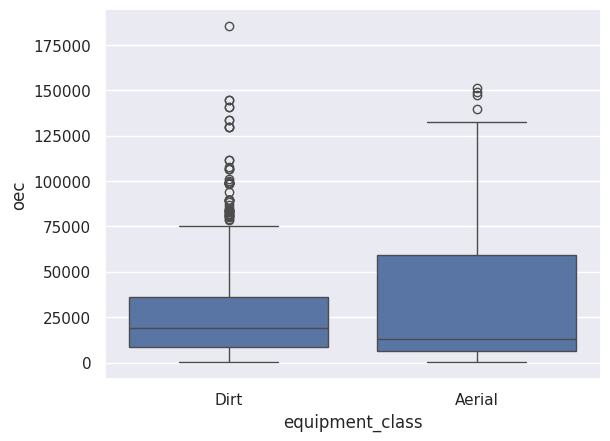

In [8]:
sns.boxplot(x='equipment_class',y='oec',data=asset_oec)

Some outliers - using my outlier function to remove those by equipment class. Might regret this later since I might need that for some of the rental data - saved as separate dataframe so I don't have to go searching later on. 

In [9]:
def remove_group_outliers(df, group_col, val_col):
    # Function to define the mask for non-outliers within a group
    def is_not_outlier(group):
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return (group >= lower) & (group <= upper)

    # Apply the mask group-wise and filter the original DataFrame
    mask = df.groupby(group_col)[val_col].transform(is_not_outlier)
    return df[mask]

df_cleaned = remove_group_outliers(asset_oec, 'equipment_class', 'oec')
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3846 entries, 11 to 3902
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   asset_id          3846 non-null   float64       
 1   market_id         3846 non-null   float64       
 2   acquisition_date  3846 non-null   datetime64[ns]
 3   equipment_class   3846 non-null   object        
 4   oec               3846 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 180.3+ KB


Alright less than 20 rows removed - that might be okay. Check boxplot again. 

<Axes: xlabel='equipment_class', ylabel='oec'>

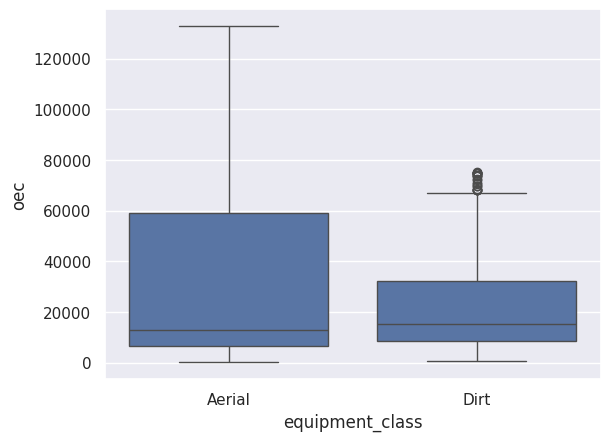

In [10]:
sns.boxplot(x='equipment_class',y='oec',data=df_cleaned)

## Rental Data

In [11]:
rentals.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34624 entries, 0 to 34623
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   rental_date     34624 non-null  datetime64[ns]
 1   rental_id       34624 non-null  int64         
 2   asset_id        34624 non-null  int64         
 3   market_id       34624 non-null  int64         
 4   rental_revenue  34624 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 1.3 MB


In [12]:
rentals.head()

,rental_date,rental_id,asset_id,market_id,rental_revenue
0,2017-01-01,1862,2015,3,1790.3736
1,2017-01-01,2056,1176,4,264.2328
2,2017-01-01,3769,1699,1,313.6896
3,2017-01-01,4400,4671,3,2581.9632
4,2017-01-01,4430,2014,3,1266.1200


In [13]:
rentals.isnull().sum()

rental_date       0
rental_id         0
asset_id          0
market_id         0
rental_revenue    0
dtype: int64

<Axes: xlabel='rental_revenue'>

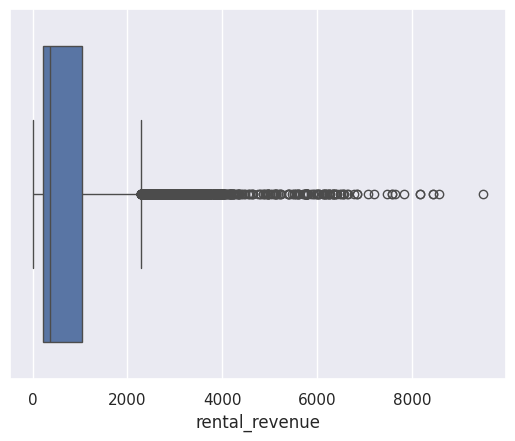

In [14]:
sns.boxplot(x='rental_revenue',data=rentals)

In [15]:
rentals['rental_revenue'].describe()

count    34624.000000
mean       752.280355
std        858.000470
min          0.000000
25%        227.167200
50%        361.411200
75%       1047.673800
max       9498.398400
Name: rental_revenue, dtype: float64

Not sure that I want to drop any outliers yet. Join all the data together first may be better

# Merge the datasets

Join rentals to the relevant market - number of rows should match rentals dataset. 

In [16]:
df = pd.merge(rentals, asset_oec, on='asset_id')
df['market_id']=df['market_id_y']
df = df.drop(['market_id_y','market_id_x'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34624 entries, 0 to 34623
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   rental_date       34624 non-null  datetime64[ns]
 1   rental_id         34624 non-null  int64         
 2   asset_id          34624 non-null  int64         
 3   rental_revenue    34624 non-null  float64       
 4   acquisition_date  34624 non-null  datetime64[ns]
 5   equipment_class   34624 non-null  object        
 6   oec               34624 non-null  float64       
 7   market_id         34624 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(1)
memory usage: 2.1+ MB


In [17]:
market_map

,market_id,market_name,market_open_date
0,1,New York City,2016-01-01
1,3,Chicago,2016-01-01
2,4,Louisville,2016-10-01
3,6,Boston,2016-02-01
4,5,Salt Lake City,2016-03-01
5,2,Phoenix,2016-09-01
6,8,Orlando,2016-12-01
7,9,Nashville,2017-03-01
8,7329,Los Angeles,2017-09-01
9,7522,Houston,2016-12-01


Join the asset dataset to it now - still should be same number across all columns

In [18]:
df['market_id']=df['market_id'].astype(int)
market_map['market_id']=market_map['market_id'].astype(int)
df1=pd.merge(df,market_map, on ='market_id',how='outer',indicator=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34624 entries, 0 to 34623
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   rental_date       34624 non-null  datetime64[ns]
 1   rental_id         34624 non-null  int64         
 2   asset_id          34624 non-null  int64         
 3   rental_revenue    34624 non-null  float64       
 4   acquisition_date  34624 non-null  datetime64[ns]
 5   equipment_class   34624 non-null  object        
 6   oec               34624 non-null  float64       
 7   market_id         34624 non-null  int64         
 8   market_name       31557 non-null  object        
 9   market_open_date  31557 non-null  datetime64[ns]
 10  _merge            34624 non-null  category      
dtypes: category(1), datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.7+ MB


Okay so these numbers tell me that we are missing some info on some of the assets in these markets that we have rental data for. Curious about the missing data 

In [19]:
df1[df1['_merge'] !='both']['rental_revenue'].sum()

np.float64(2195235.7416000003)

In [20]:
df1['market_name']=df1['market_name'].fillna(df1['market_id'].astype(int))
df1['market_name'].unique()
#df1[df1['market_name']==3]
#df1[df1['market_name'].isnull()==True]['market_id'].unique()

array(['New York City', 'Phoenix', 'Chicago', 'Louisville',
       'Salt Lake City', 'Boston', 'Orlando', 'Nashville', 6877,
       'Los Angeles', 'Houston', 7669, 7670, 7672, 8135, 8606, 8631, 8632,
       8633, 10313, 10328, 10525, 10744, 11007], dtype=object)

In [21]:
df1=df1[df1['_merge'] =='both']

In [22]:
df1.isnull().sum()
#df_missing.head()

rental_date         0
rental_id           0
asset_id            0
rental_revenue      0
acquisition_date    0
equipment_class     0
oec                 0
market_id           0
market_name         0
market_open_date    0
_merge              0
dtype: int64

# Graphing some in Tableau for Analysis
### Chicago is an outlier - much more invested here than anywhere else especially for aerial so more revenue

In [23]:
df1[df1['acquisition_date']<df1['market_open_date']]

,rental_date,rental_id,asset_id,rental_revenue,acquisition_date,equipment_class,oec,market_id,market_name,market_open_date,_merge
2051,2017-01-01,7198,3533,241.3872,2016-01-01,Aerial,7302.9600,2,Phoenix,2016-09-01,both
2052,2017-01-01,7856,587,237.5280,2016-01-01,Aerial,6782.4000,2,Phoenix,2016-09-01,both
2053,2017-01-01,10078,3573,252.3672,2016-01-01,Aerial,7302.9600,2,Phoenix,2016-09-01,both
2054,2017-01-01,11662,3567,240.6456,2016-01-01,Aerial,7302.9600,2,Phoenix,2016-09-01,both
2055,2017-01-01,12642,1889,301.7160,2016-01-01,Aerial,9273.8880,2,Phoenix,2016-09-01,both
...,...,...,...,...,...,...,...,...,...,...,...
32612,2017-12-01,40769,5533,38.8800,2016-01-01,Aerial,4968.0000,7522,Houston,2016-12-01,both
32615,2017-12-01,40778,5510,25.9200,2016-01-01,Aerial,4968.0000,7522,Houston,2016-12-01,both
32619,2017-12-01,40823,5510,49.4856,2016-01-01,Aerial,4968.0000,7522,Houston,2016-12-01,both
32620,2017-12-01,40827,5524,50.3568,2016-01-01,Aerial,4968.0000,7522,Houston,2016-12-01,both


Could have acquired the asset prior to market opening so ok - couldn't have rented asset in a market before acquistion date or market open date

In [24]:
df1[df1['rental_date']<df1['market_open_date']]['rental_revenue'].sum()


np.float64(1074044.0664)

In [25]:
df1['rental_revenue'].sum()

np.float64(23851719.2592)

Impact of removing assets where it was rented before the market was open = $717,297.38

In [26]:
df1= df1[df1['rental_date']>=df1['market_open_date']]

In [27]:
df1[df1['rental_date']<df1['acquisition_date']]['rental_revenue'].sum()

np.float64(468087.2136)

Impact of removing assets where it was rented before it was acquired = $517,661.78

In [28]:
df1=df1[df1['rental_date']>=df1['acquisition_date']]
df1

,rental_date,rental_id,asset_id,rental_revenue,acquisition_date,equipment_class,oec,market_id,market_name,market_open_date,_merge
0,2017-01-01,3769,1699,313.6896,2016-01-01,Aerial,6669.8640,1,New York City,2016-01-01,both
1,2017-01-01,4844,699,2429.8776,2016-01-01,Aerial,60840.0000,1,New York City,2016-01-01,both
2,2017-01-01,6884,3527,238.5576,2016-01-01,Aerial,5839.2000,1,New York City,2016-01-01,both
3,2017-01-01,6885,1221,240.8040,2016-01-01,Aerial,9258.1992,1,New York City,2016-01-01,both
4,2017-01-01,7006,1222,281.2680,2016-01-01,Aerial,9258.1992,1,New York City,2016-01-01,both
...,...,...,...,...,...,...,...,...,...,...,...
32623,2017-12-01,40850,19009,270.0000,2017-12-01,Aerial,68554.8000,7522,Houston,2016-12-01,both
32624,2017-12-01,40891,16159,194.4000,2017-10-01,Aerial,61953.8400,7522,Houston,2016-12-01,both
32625,2017-12-01,40978,18329,609.2280,2017-10-01,Aerial,58320.0000,7522,Houston,2016-12-01,both
32626,2017-12-01,41073,10455,486.0000,2017-05-01,Aerial,52885.4400,7522,Houston,2016-12-01,both


Wait oec should only apply once for each asset so merging all like this doesn't really work... 

In [29]:
#df = pd.merge(rentals, market_map, on='market_id')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30370 entries, 0 to 32627
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   rental_date       30370 non-null  datetime64[ns]
 1   rental_id         30370 non-null  int64         
 2   asset_id          30370 non-null  int64         
 3   rental_revenue    30370 non-null  float64       
 4   acquisition_date  30370 non-null  datetime64[ns]
 5   equipment_class   30370 non-null  object        
 6   oec               30370 non-null  float64       
 7   market_id         30370 non-null  int64         
 8   market_name       30370 non-null  object        
 9   market_open_date  30370 non-null  datetime64[ns]
 10  _merge            30370 non-null  category      
dtypes: category(1), datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.6+ MB


Okay what I want is market - number of assets in dirt, revenue in dirt, oec in dirt, same metrics for aerial - then get the mix, the revenue for the year and oec for the year. Aquisition date should be used to calculate when oec applies for financial utilization

# SQL 

In [30]:
import duckdb

# Run a query and output directly to the console
revenue_sql= duckdb.sql('''
    select
        r.market_id,
        max(date_part('days',(coalesce(rental_date,acquisition_date)-market_open_date))) as "Days since Market Open",
        (sum(rental_revenue)/count(distinct rental_date))*12 as rental_revenue
    from df1 r
    group by 1''')
revenue_sql.df()

,market_id,Days since Market Open,rental_revenue
0,3,700,6.369369e+06
1,4,426,3.770767e+05
2,6,669,9.945087e+05
3,7329,91,1.805939e+06
4,1,700,1.100525e+06
5,8,365,3.571720e+06
6,2,456,1.110419e+06
7,5,640,2.898247e+06
8,9,275,5.323128e+06
9,7522,365,8.498041e+05


In [31]:
df1

,rental_date,rental_id,asset_id,rental_revenue,acquisition_date,equipment_class,oec,market_id,market_name,market_open_date,_merge
0,2017-01-01,3769,1699,313.6896,2016-01-01,Aerial,6669.8640,1,New York City,2016-01-01,both
1,2017-01-01,4844,699,2429.8776,2016-01-01,Aerial,60840.0000,1,New York City,2016-01-01,both
2,2017-01-01,6884,3527,238.5576,2016-01-01,Aerial,5839.2000,1,New York City,2016-01-01,both
3,2017-01-01,6885,1221,240.8040,2016-01-01,Aerial,9258.1992,1,New York City,2016-01-01,both
4,2017-01-01,7006,1222,281.2680,2016-01-01,Aerial,9258.1992,1,New York City,2016-01-01,both
...,...,...,...,...,...,...,...,...,...,...,...
32623,2017-12-01,40850,19009,270.0000,2017-12-01,Aerial,68554.8000,7522,Houston,2016-12-01,both
32624,2017-12-01,40891,16159,194.4000,2017-10-01,Aerial,61953.8400,7522,Houston,2016-12-01,both
32625,2017-12-01,40978,18329,609.2280,2017-10-01,Aerial,58320.0000,7522,Houston,2016-12-01,both
32626,2017-12-01,41073,10455,486.0000,2017-05-01,Aerial,52885.4400,7522,Houston,2016-12-01,both


In [32]:
dates = duckdb.sql('''
    select
        distinct d.rental_date
    from  df1 d 
    left join market_map m on 1=1
    ''')
dates.df()


,rental_date
0,2017-08-01
1,2017-01-01
2,2017-02-01
3,2017-03-01
4,2017-06-01
5,2017-09-01
6,2017-11-01
7,2017-12-01
8,2017-05-01
9,2017-07-01


In [33]:
oec = duckdb.sql('''
select 
        market_id,
        acquisition_date as month,
        SUM(CASE WHEN equipment_class = 'Dirt' then oec end) AS dirt_monthly_oec,
        SUM(CASE WHEN equipment_class = 'Aerial' then oec end) AS aerial_monthly_oec,
        sum(oec) as total_monthly_oec
        FROM asset_oec group by 1,2''')

monthly_revenue=duckdb.sql(''' 
    SELECT
        coalesce(a.market_id,r.market_id) as market_id,
        coalesce(rental_date,acquisition_date) AS month,
        SUM(CASE WHEN equipment_class = 'Dirt' THEN rental_revenue ELSE 0 END) AS dirt_monthly_revenue,
        SUM(CASE WHEN equipment_class = 'Aerial' THEN rental_revenue ELSE 0 END)  AS aerial_monthly_revenue
        ,coalesce(sum(rental_revenue),0) as total_monthly_revenue
    FROM asset_oec a
    left outer join rentals r on a.asset_id=r.asset_id
    and (r.rental_date>=a.acquisition_date or r.rental_date is null)
    GROUP BY
        1,2''')

monthly=duckdb.sql('''
    SELECT
        coalesce(o.market_id,r.market_id) AS market_id,m.market_name,
        coalesce(o.month, r.month) AS month,

        COALESCE(o.dirt_monthly_oec, 0) AS dirt_monthly_oec,
        COALESCE(o.aerial_monthly_oec, 0) AS aerial_monthly_oec,
        COALESCE(o.total_monthly_oec, 0) AS total_monthly_oec,

        COALESCE(r.dirt_monthly_revenue, 0) AS dirt_monthly_revenue,
        COALESCE(r.aerial_monthly_revenue, 0) AS aerial_monthly_revenue,
        COALESCE(r.total_monthly_revenue, 0) AS total_monthly_revenue,
        datediff('month',coalesce(o.month,r.month),m.market_open_date) as market_age_months

    FROM oec o
    FULL OUTER JOIN monthly_revenue r
        ON o.market_id = r.market_id
       AND o.month = r.month
    left outer  join market_map m on (m.market_id=r.market_id or m.market_id = o.market_id) and (r.month>=m.market_open_date  or r.month is null)
       where market_name is not null 
       ''')

print(oec.df()['total_monthly_oec'].sum()-monthly.df()['total_monthly_oec'].sum())
print(monthly.df()['total_monthly_revenue'].sum())

16411361.399999976
22309587.979200006


In [34]:
annual =duckdb.sql('''select market_id, sum(dirt_monthly_revenue) as dirt_annual_revenue, 
sum(aerial_monthly_revenue) as aerial_annual_revenue,
sum(total_monthly_revenue) as total_annual_revenue, count(month) as "Number of Months"
from monthly group by 1''')

running = duckdb.sql('''
    SELECT
        market_id,market_name,
        month, market_age_months,

        dirt_monthly_revenue,
        aerial_monthly_revenue,
        total_monthly_revenue,
        dirt_monthly_oec, aerial_monthly_oec, total_monthly_oec,

        SUM(dirt_monthly_oec) OVER (
            PARTITION BY market_id
            ORDER BY month
        ) AS dirt_running_oec,

        SUM(aerial_monthly_oec) OVER (
            PARTITION BY market_id
            ORDER BY month
        ) AS aerial_running_oec,
        SUM(total_monthly_oec) OVER (
            PARTITION BY market_id
            ORDER BY month
        ) AS total_running_oec

    FROM monthly''')

addann =duckdb.sql('''select r.*,
(a.dirt_annual_revenue/"Number of Months") as dirt_annualized_revenue,
(a.aerial_annual_revenue/"Number of Months") as aerial_annualized_revenue,
(a.total_annual_revenue/"Number of Months") as total_annualized_revenue
from running r left join annual a on a.market_id=r.market_id ''')
lastone =duckdb.sql('''SELECT
    market_name,
    month,market_age_months,
    dirt_monthly_revenue,
        aerial_monthly_revenue,
        total_monthly_revenue,
    dirt_monthly_oec, aerial_monthly_oec, total_monthly_oec,
    dirt_running_oec,
    aerial_running_oec,
    total_running_oec,

    dirt_running_oec / NULLIF(dirt_running_oec + aerial_running_oec, 0) AS dirt_mix,
    aerial_running_oec / NULLIF(dirt_running_oec + aerial_running_oec, 0) AS aerial_mix,
    dirt_annualized_revenue , aerial_annualized_revenue, total_annualized_revenue ,

    dirt_annualized_revenue / NULLIF(dirt_running_oec, 0) AS dirt_financial_utilization,
    aerial_annualized_revenue / NULLIF(aerial_running_oec, 0) AS aerial_financial_utilization,
    total_annualized_revenue / NULLIF(total_running_oec, 0) AS total_financial_utilization

FROM  addann
ORDER BY
    1,2''')

#print(df1['rental_revenue'].sum())
#print(asset_oec['oec'].sum())
#print(lastone.df()['total_annualized_revenue'].sum())
#print(lastone.df()['total_monthly_oec'].sum())
#print(oec.df())
#print(rentals['rental_revenue'].sum())
#print(monthly_revenue.df()['rental_revenue'].sum())
#print(rentals['rental_revenue'].sum()-monthly_revenue.df()['rental_revenue'].sum())
#print(monthly.df()['total_monthly_oec'].sum())
#print(monthly_revenue.df()['total_monthly_revenue'].sum()-monthly.df()['total_monthly_revenue'].sum())
#print(monthly.df()['total_monthly_revenue'].sum())
#print(annual.df()['total_annual_revenue'].sum())
#print(monthly.df())
#print(lastone.df()['total_monthly_revenue'].sum())
print(lastone.df()['total_monthly_oec'].sum())
#print(lastone.df())
df=lastone.df()
print(df.columns)

101430592.77600005
Index(['market_name', 'month', 'market_age_months', 'dirt_monthly_revenue',
       'aerial_monthly_revenue', 'total_monthly_revenue', 'dirt_monthly_oec',
       'aerial_monthly_oec', 'total_monthly_oec', 'dirt_running_oec',
       'aerial_running_oec', 'total_running_oec', 'dirt_mix', 'aerial_mix',
       'dirt_annualized_revenue', 'aerial_annualized_revenue',
       'total_annualized_revenue', 'dirt_financial_utilization',
       'aerial_financial_utilization', 'total_financial_utilization'],
      dtype='object')


In [35]:
df

,market_name,month,market_age_months,dirt_monthly_revenue,aerial_monthly_revenue,total_monthly_revenue,dirt_monthly_oec,aerial_monthly_oec,total_monthly_oec,dirt_running_oec,aerial_running_oec,total_running_oec,dirt_mix,aerial_mix,dirt_annualized_revenue,aerial_annualized_revenue,total_annualized_revenue,dirt_financial_utilization,aerial_financial_utilization,total_financial_utilization
0,Boston,2016-01-01,1,0.0000,0.0000,0.0000,228018.9384,2.084288e+06,2.312306e+06,2.280189e+05,2.084288e+06,2.312306e+06,0.098611,0.901389,11248.518857,59787.816171,71036.335029,0.049332,0.028685,0.030721
1,Boston,2016-12-01,-10,0.0000,0.0000,0.0000,80640.0000,1.186111e+05,1.992511e+05,3.086589e+05,2.202899e+06,2.511558e+06,0.122895,0.877105,11248.518857,59787.816171,71036.335029,0.036443,0.027141,0.028284
2,Boston,2017-01-01,-11,4440.4560,45852.4080,50292.8640,0.0000,0.000000e+00,0.000000e+00,3.086589e+05,2.202899e+06,2.511558e+06,0.122895,0.877105,11248.518857,59787.816171,71036.335029,0.036443,0.027141,0.028284
3,Boston,2017-02-01,-12,3786.4944,51802.7256,55589.2200,0.0000,1.249737e+05,1.249737e+05,3.086589e+05,2.327872e+06,2.636531e+06,0.117070,0.882930,11248.518857,59787.816171,71036.335029,0.036443,0.025683,0.026943
4,Boston,2017-03-01,-13,10105.5888,58042.6344,68148.2232,88907.7600,4.374535e+05,5.263612e+05,3.975667e+05,2.765326e+06,3.162892e+06,0.125697,0.874303,11248.518857,59787.816171,71036.335029,0.028293,0.021621,0.022459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Salt Lake City,2017-08-01,-17,44870.7384,220234.8600,265105.5984,27566.6400,1.916928e+05,2.192594e+05,1.757390e+06,9.013970e+06,1.077136e+07,0.163154,0.836846,41884.233785,181057.824000,222942.057785,0.023833,0.020086,0.020698
126,Salt Lake City,2017-09-01,-18,51884.4816,201654.0720,253538.5536,124706.1600,2.981866e+05,4.228927e+05,1.882096e+06,9.312156e+06,1.119425e+07,0.168131,0.831869,41884.233785,181057.824000,222942.057785,0.022254,0.019443,0.019916
127,Salt Lake City,2017-10-01,-19,56868.5520,214458.0408,271326.5928,103656.9600,2.823077e+05,3.859646e+05,1.985753e+06,9.594464e+06,1.158022e+07,0.171478,0.828522,41884.233785,181057.824000,222942.057785,0.021092,0.018871,0.019252
128,Salt Lake City,2017-11-01,-20,62051.7744,209992.6872,272044.4616,0.0000,5.452560e+03,5.452560e+03,1.985753e+06,9.599916e+06,1.158567e+07,0.171397,0.828603,41884.233785,181057.824000,222942.057785,0.021092,0.018860,0.019243


In [36]:
df.isnull().sum()
df.to_excel('df.xlsx')

# Modeling

## Linear Regression

In [37]:
import statsmodels.formula.api as smf
model = smf.ols(
    """
    Q("total_annualized_revenue")
    ~ Q("dirt_mix")
    +C(market_name) +Q("total_monthly_oec") + Q("total_running_oec")+Q("dirt_monthly_oec")
    +Q("aerial_monthly_oec")+Q("aerial_mix")+Q("dirt_running_oec")+Q("aerial_running_oec")
    """,
    data=df
).fit()
print(model.summary())


                                  OLS Regression Results                                 
Dep. Variable:     Q("total_annualized_revenue")   R-squared:                       1.000
Model:                                       OLS   Adj. R-squared:                  1.000
Method:                            Least Squares   F-statistic:                 5.846e+17
Date:                           Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                                   23:48:26   Log-Likelihood:                 804.72
No. Observations:                            130   AIC:                            -1579.
Df Residuals:                                115   BIC:                            -1536.
Df Model:                                     14                                         
Covariance Type:                       nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]

In [38]:
model = smf.ols(
    """
    total_annualized_revenue
    ~ dirt_mix
    + total_monthly_oec
    + C(market_name)
    """,
    data=df
).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     total_annualized_revenue   R-squared:                       1.000
Model:                                  OLS   Adj. R-squared:                  1.000
Method:                       Least Squares   F-statistic:                 8.671e+18
Date:                      Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                              23:48:26   Log-Likelihood:                 962.66
No. Observations:                       130   AIC:                            -1901.
Df Residuals:                           118   BIC:                            -1867.
Df Model:                                11                                         
Covariance Type:                  nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [39]:
model_rev = smf.ols(
    """
    total_annualized_revenue
    ~ dirt_mix * total_running_oec
    + C(market_name)
    """,
    data=df
).fit()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     total_annualized_revenue   R-squared:                       1.000
Model:                                  OLS   Adj. R-squared:                  1.000
Method:                       Least Squares   F-statistic:                 8.671e+18
Date:                      Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                              23:48:26   Log-Likelihood:                 962.66
No. Observations:                       130   AIC:                            -1901.
Df Residuals:                           118   BIC:                            -1867.
Df Model:                                11                                         
Covariance Type:                  nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [40]:
model = smf.ols(
    """
    total_monthly_revenue
    ~ dirt_mix
    + total_running_oec
    + market_age_months
    """,
    data=df
).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     total_monthly_revenue   R-squared:                       0.796
Model:                               OLS   Adj. R-squared:                  0.791
Method:                    Least Squares   F-statistic:                     164.0
Date:                   Wed, 10 Jun 2026   Prob (F-statistic):           2.48e-43
Time:                           23:48:26   Log-Likelihood:                -1653.7
No. Observations:                    130   AIC:                             3315.
Df Residuals:                        126   BIC:                             3327.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercep

In [41]:
model = smf.ols(
    """
    total_monthly_revenue
    ~ dirt_mix
    + total_running_oec
    + market_age_months
    + dirt_mix:market_age_months
    """,
    data=df
).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     total_monthly_revenue   R-squared:                       0.798
Model:                               OLS   Adj. R-squared:                  0.792
Method:                    Least Squares   F-statistic:                     123.8
Date:                   Wed, 10 Jun 2026   Prob (F-statistic):           1.73e-42
Time:                           23:48:26   Log-Likelihood:                -1653.0
No. Observations:                    130   AIC:                             3316.
Df Residuals:                        125   BIC:                             3330.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [42]:
results = []

for market in sorted(df.market_name.unique()):

    row = (
        df[df.market_name == market]
        .sort_values("month")
        .iloc[-1]
    )

    current = row["aerial_mix"]

    # only evaluate nearby moves
    candidate_mixes = [
        max(.05, current-.10),
        max(.05, current-.05),
        current,
        min(.95, current+.05),
        min(.95, current+.10)
    ]

    for mix in candidate_mixes:

        temp = row.copy()
        temp["aerial_mix"] = mix

        pred_rev = model.predict(
            pd.DataFrame([temp])
        ).iloc[0]

        results.append({
            "market": market,
            "current_mix": current,
            "test_mix": mix,
            "pred_rev": pred_rev*12/100000,
            "current_rev": row["total_monthly_revenue"]*12/100000
        })

rec = pd.DataFrame(results)

rec["rev_change"] = (
    rec["pred_rev"]
    - rec["current_rev"]
)



recommendations = (
    rec
    .sort_values(
        ["market","pred_rev"],
        ascending=[True,False]
    )
    .groupby("market")
    .first()
    .reset_index()
)

recommendations

,market,current_mix,test_mix,pred_rev,current_rev,rev_change
0,Boston,0.836305,0.736305,18.133030,15.461804,2.671226
1,Chicago,0.960048,0.860048,69.798004,78.970322,-9.172319
2,Houston,0.962802,0.862802,6.052322,12.131723,-6.079401
3,Los Angeles,0.897524,0.797524,8.628534,25.314458,-16.685924
4,Louisville,0.882522,0.782522,8.964958,5.595248,3.369710
5,Nashville,0.597644,0.497644,67.390910,78.242919,-10.852009
6,New York City,0.858590,0.758590,17.874680,13.100443,4.774236
7,Orlando,0.867218,0.767218,46.584040,66.191832,-19.607792
8,Phoenix,0.886074,0.786074,17.808693,13.805488,4.003205
9,Salt Lake City,0.830510,0.730510,37.794041,35.769098,2.024943


In [43]:
results = []

for market in sorted(df.market_name.unique()):

    row = (
        df[df.market_name == market]
        .sort_values("month")
        .iloc[-1]
    )

    current = row["dirt_mix"]

    candidate_mixes = [
        max(.05, current-.10),
        max(.05, current-.05),
        current,
        min(.95, current+.05),
        min(.95, current+.10)
    ]

    for mix in candidate_mixes:

        temp = row.copy()
        temp["dirt_mix"] = mix

        pred_rev = model.predict(pd.DataFrame([temp])).iloc[0]
        pred_util = model_util.predict(pd.DataFrame([temp])).iloc[0]

        results.append({
            "market": market,
            "current_mix": current,
            "test_mix": mix,
            "current_rev": row["total_monthly_revenue"],
            "pred_rev": pred_rev,
            "current_util": row["total_financial_utilization"],
            "pred_util": pred_util
        })

rec = pd.DataFrame(results)

rec["rev_change"] = ((rec["pred_rev"] - rec["current_rev"])*12)/100000
rec["rev_change_pct"] = rec["rev_change"] / rec["current_rev"]

rec["util_change"] = rec["pred_util"] - rec["current_util"]
rec["util_change_pct"] = rec["util_change"] / rec["current_util"]

scenario_table = rec.sort_values(["market", "test_mix"])

scenario_table

NameError: name 'model_util' is not defined

In [ ]:
model_util = smf.ols(
    """
    dirt_financial_utilization
    ~ dirt_mix
    + market_age_months
    + dirt_mix:market_age_months
    """,
    data=df
).fit()

print(model_util.summary())

In [ ]:
results = []

for market in sorted(df.market_name.unique()):

    row = (
        df[df.market_name == market]
        .sort_values("month")
        .iloc[-1]
    )

    for mix in np.arange(0, .81, .05):

        temp = row.copy()
        temp["dirt_mix"] = mix

        pred_rev = (
            model.predict(
                pd.DataFrame([temp])
            ).iloc[0]
        )

        pred_util = (
            model_util.predict(
                pd.DataFrame([temp])
            ).iloc[0]
        )

        results.append({
            "market": market,
            "current_mix": row["dirt_mix"],
            "test_mix": mix,
            "pred_rev": pred_rev,
            "pred_util": pred_util,
            "current_rev": row["total_annualized_revenue"],
            "current_util": row["total_financial_utilization"]
        })

rec = pd.DataFrame(results)

In [ ]:
rec["rev_change_pct"] = (
    rec["pred_rev"]
    - rec["current_rev"]
) / rec["current_rev"]

rec["util_change"] = (
    rec["pred_util"]
    - rec["current_util"]
)
rec["rev_rank"] = (
    rec.groupby("market")["rev_change_pct"]
    .rank(pct=True)
)

rec["util_rank"] = (
    rec.groupby("market")["util_change"]
    .rank(pct=True)
)

rec["combined_score"] = (
    rec["rev_rank"] * .6
    + rec["util_rank"] * .4
)